In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os

DB_FILE = 'Music_Streaming_Service.db'
assert os.path.exists(DB_FILE), f'{DB_FILE} not found in working directory.'

conn = sqlite3.connect(DB_FILE)

# Helper: run a SELECT and return a DataFrame
def query(sql, params=()):
    return pd.read_sql_query(sql, conn, params=params)

# Helper: run a non-SELECT statement
def execute(sql, params=()):
    cur = conn.cursor()
    cur.execute(sql, params)
    conn.commit()
    return cur.rowcount

# Confirm load
tables = query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
counts = []
for t in tables['name']:
    n = query(f'SELECT COUNT(*) AS n FROM {t}').iloc[0]['n']
    counts.append((t, n))
pd.DataFrame(counts, columns=['table', 'rows'])


,table,rows
0,Album,31
1,Artist,25
2,Device,10
3,Genre,18
4,Playlist,30
5,PlaylistSong,466
6,Region,10
7,Song,380
8,SongGenre,570
9,SubscriptionPlan,4


In [2]:
def add_device(device_id, name, device_type):
    return execute(
        'INSERT INTO Device (device_id, name, type) VALUES (?, ?, ?)',
        (device_id, name, device_type)
    )

def link_user_device(user_device_id, user_id, device_id):
    return execute(
        'INSERT INTO UserDevice (user_device_id, user_id, device_id) VALUES (?, ?, ?)',
        (user_device_id, user_id, device_id)
    )

add_device(11, 'Sonos One', 'Smart Speaker')
link_user_device(69, 1, 11)
query("SELECT * FROM Device WHERE device_id = 11")


,device_id,name,type
0,11,Sonos One,Smart Speaker


In [3]:
def create_playlist(playlist_id, user_id, name):
    execute('INSERT INTO Playlist (playlist_id, user_id, name) VALUES (?, ?, ?)',
            (playlist_id, user_id, name))
    execute('INSERT INTO UserPlaylist (user_playlist_id, user_id, playlist_id) VALUES (?, ?, ?)',
            (playlist_id + 75, user_id, playlist_id))  # user_playlist_id offset past the 105 existing rows

def add_song_to_playlist(playlist_song_id, playlist_id, song_id):
    return execute(
        'INSERT INTO PlaylistSong (playlist_song_id, playlist_id, song_id) VALUES (?, ?, ?)',
        (playlist_song_id, playlist_id, song_id)
    )

create_playlist(31, 1, 'Late Night Coding')
add_song_to_playlist(467, 31, 2)
add_song_to_playlist(468, 31, 15)
query("SELECT * FROM Playlist WHERE playlist_id = 31")


,playlist_id,user_id,name
0,31,1,Late Night Coding


In [4]:
def user_playlists(user_id):
    return query('''
        SELECT p.playlist_id, p.name AS playlist_name, COUNT(ps.song_id) AS song_count
        FROM Playlist p
        LEFT JOIN PlaylistSong ps ON p.playlist_id = ps.playlist_id
        WHERE p.user_id = ?
        GROUP BY p.playlist_id, p.name
    ''', (user_id,))

user_playlists(41)


,playlist_id,playlist_name,song_count
0,1,Workout Mix,22


In [5]:
def user_devices(user_id):
    return query('''
        SELECT d.device_id, d.name, d.type
        FROM Device d
        JOIN UserDevice ud ON d.device_id = ud.device_id
        WHERE ud.user_id = ?
    ''', (user_id,))

user_devices(1)


,device_id,name,type
0,8,Samsung Galaxy Tab S8,Tablet
1,11,Sonos One,Smart Speaker


In [6]:
def songs_by_genre(genre_name):
    return query('''
        SELECT s.song_id, s.title, s.duration
        FROM Song s
        JOIN SongGenre sg ON s.song_id = sg.song_id
        JOIN Genre g ON sg.genre_id = g.genre_id
        WHERE g.name = ?
    ''', (genre_name,))

songs_by_genre('Pop').head(10)


,song_id,title,duration
0,14,Why You Wanna Trip On Me,5:25
1,17,Remember the Time,4:00
2,18,Can't Let Her Get Away,5:01
3,19,Heal the World,6:24
4,20,Black or White,4:16
5,22,Give In to Me,5:29
6,23,Will You Be There,7:39
7,24,Keep the Faith,5:58
8,39,All That She Wants (2015 Remastered Version),3:31
9,40,Don't Turn Around (2015 Remastered Version,3:50


In [7]:
def rename_playlist(playlist_id, new_name):
    return execute('UPDATE Playlist SET name = ? WHERE playlist_id = ?',
                   (new_name, playlist_id))

rename_playlist(1, 'Morning Workout Mix')
query('SELECT * FROM Playlist WHERE playlist_id = 1')


,playlist_id,user_id,name
0,1,41,Morning Workout Mix


In [8]:
def reassign_genre(song_id, old_genre_id, new_genre_id):
    return execute('UPDATE SongGenre SET genre_id = ? WHERE song_id = ? AND genre_id = ?',
                   (new_genre_id, song_id, old_genre_id))

reassign_genre(song_id=10, old_genre_id=1, new_genre_id=6)
query('SELECT * FROM SongGenre WHERE song_id = 10')


,song_genre_id,song_id,genre_id
0,16,10,14


In [9]:
def remove_song_from_playlist(playlist_id, song_id):
    return execute('DELETE FROM PlaylistSong WHERE playlist_id = ? AND song_id = ?',
                   (playlist_id, song_id))

remove_song_from_playlist(31, 15)
query('SELECT * FROM PlaylistSong WHERE playlist_id = 31')


,playlist_song_id,playlist_id,song_id
0,467,31,2


In [10]:
def unlink_user_device(user_id, device_id):
    return execute('DELETE FROM UserDevice WHERE user_id = ? AND device_id = ?',
                   (user_id, device_id))

unlink_user_device(1, 11)
query('SELECT * FROM UserDevice WHERE user_id = 1')


,user_device_id,user_id,device_id
0,36,1,8


In [11]:
def user_playlist_contents(user_id):
    return query('''
        SELECT u.name AS user_name,
               p.name AS playlist_name,
               s.title AS song_title,
               al.title AS album_title,
               ar.name AS artist_name
        FROM User u
        JOIN Playlist p ON u.user_id = p.user_id
        JOIN PlaylistSong ps ON p.playlist_id = ps.playlist_id
        JOIN Song s ON ps.song_id = s.song_id
        JOIN Album al ON s.album_id = al.album_id
        JOIN Artist ar ON al.artist_id = ar.artist_id
        WHERE u.user_id = ?
        ORDER BY p.name, s.title
    ''', (user_id,))

user_playlist_contents(41)


,user_name,playlist_name,song_title,album_title,artist_name
0,Carter Turner,Morning Workout Mix,After the Glitter Fades,Bella Donna (2016 Remaster),Stevie Nicks
1,Carter Turner,Morning Workout Mix,Bad,Bad,Michael Jackson
2,Carter Turner,Morning Workout Mix,Better That We Break,It Won't Be Soon Before Long,Maroon 5
3,Carter Turner,Morning Workout Mix,Big Love (Remastered),Tango in the Night (Remastered),Fleetwood Mac
4,Carter Turner,Morning Workout Mix,Dancer in a Daydram (2015 Remastered Version),The Sign (2015 Remasterd Version),Ace of Base
5,Carter Turner,Morning Workout Mix,Dream of the Archer,Little Queen,Heart
6,Carter Turner,Morning Workout Mix,Hit the Floor,Meteora (Deluxe Version),LINKIN PARK
7,Carter Turner,Morning Workout Mix,I Still Do,"Everybody Else Is Doing It, So Why Can't We",The Cranberries
8,Carter Turner,Morning Workout Mix,I Will Always,"Everybody Else Is Doing It, So Why Can't We",The Cranberries
9,Carter Turner,Morning Workout Mix,I'll Be Waiting,21,Adele


In [12]:
def top_genres(limit=5):
    return query('''
        SELECT g.name AS genre, COUNT(sg.song_id) AS song_count
        FROM Genre g
        JOIN SongGenre sg ON g.genre_id = sg.genre_id
        GROUP BY g.genre_id, g.name
        ORDER BY song_count DESC
        LIMIT ?
    ''', (limit,))

df = top_genres(5)
df


,genre,song_count
0,Pop,136
1,Pop Rock,68
2,Alternative Rock,40
3,Soul,37
4,Rock,33


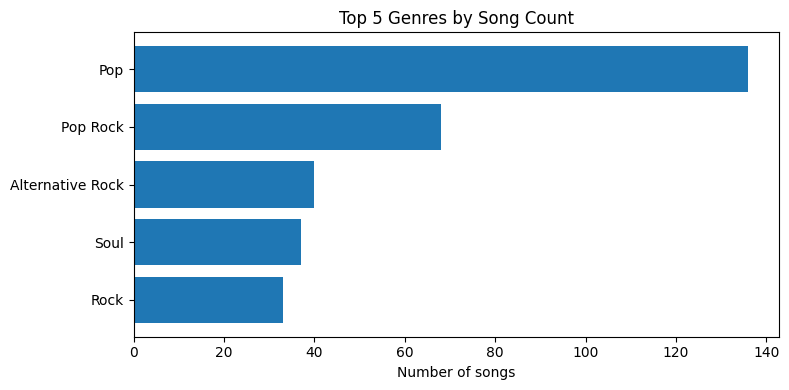

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df['genre'][::-1], df['song_count'][::-1])
ax.set_xlabel('Number of songs')
ax.set_title('Top 5 Genres by Song Count')
plt.tight_layout()
plt.show()


In [14]:
def most_popular_songs(limit=10):
    return query('''
        SELECT s.title, ar.name AS artist, COUNT(ps.playlist_id) AS times_added
        FROM Song s
        JOIN Album al ON s.album_id = al.album_id
        JOIN Artist ar ON al.artist_id = ar.artist_id
        JOIN PlaylistSong ps ON s.song_id = ps.song_id
        GROUP BY s.song_id, s.title, ar.name
        ORDER BY times_added DESC, s.title
        LIMIT ?
    ''', (limit,))

df = most_popular_songs(10)
df


,title,artist,times_added
0,Real World,The All-American Rejects,6
1,Blur,Britney Spears,5
2,I Found a Boy,Adele,5
3,It's Saturday Night,The Proclaimers,5
4,Better That We Break,Maroon 5,4
5,Breaking the Habit,LINKIN PARK,4
6,Candy Paint,Post Malone,4
7,Everybody's Fool,Evanescence,4
8,Love Alive,Heart,4
9,My Baby,Britney Spears,4


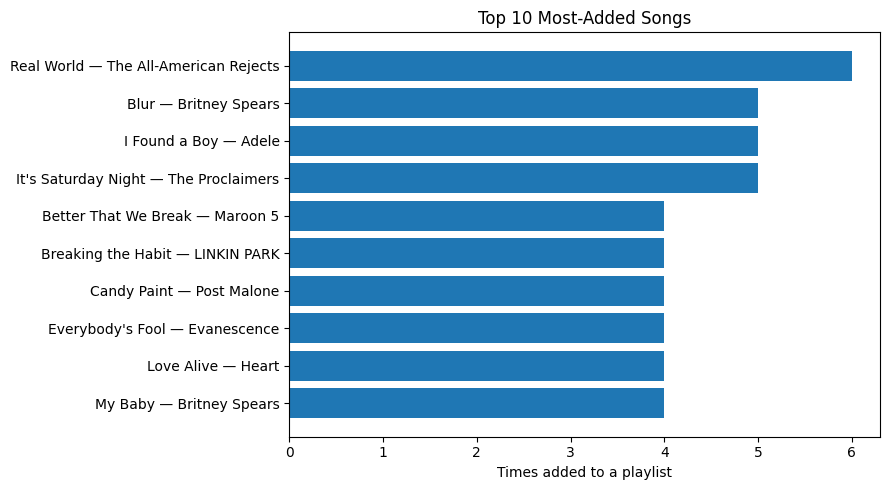

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = df.apply(lambda r: f"{r['title']} — {r['artist']}", axis=1)
ax.barh(labels[::-1], df['times_added'][::-1])
ax.set_xlabel('Times added to a playlist')
ax.set_title('Top 10 Most-Added Songs')
plt.tight_layout()
plt.show()


In [16]:
def users_by_playlist_count(limit=10):
    return query('''
        SELECT u.user_id, u.name, COUNT(p.playlist_id) AS playlists_owned
        FROM User u
        JOIN Playlist p ON u.user_id = p.user_id
        GROUP BY u.user_id, u.name
        ORDER BY playlists_owned DESC
        LIMIT ?
    ''', (limit,))

users_by_playlist_count(10)


,user_id,name,playlists_owned
0,2,Maria Garcia,3
1,6,Elena Rossi,3
2,15,Lucas Petro,3
3,18,Ava Davies,3
4,48,Grace Flores,3
5,1,James Wilson,1
6,3,Robert Chen,1
7,7,Liam O'Connor,1
8,8,Chloe Dubois,1
9,9,Yuki Tanaka,1


In [17]:
def avg_playlist_length_per_user():
    return query('''
        SELECT u.user_id, u.name, ROUND(AVG(song_count), 2) AS avg_playlist_length
        FROM User u
        JOIN Playlist p ON u.user_id = p.user_id
        JOIN (
            SELECT playlist_id, COUNT(song_id) AS song_count
            FROM PlaylistSong
            GROUP BY playlist_id
        ) pc ON p.playlist_id = pc.playlist_id
        GROUP BY u.user_id, u.name
        ORDER BY avg_playlist_length DESC
    ''')

avg_playlist_length_per_user().head(10)


,user_id,name,avg_playlist_length
0,28,Ella Young,25.0
1,7,Liam O'Connor,24.0
2,41,Carter Turner,22.0
3,8,Chloe Dubois,20.0
4,9,Yuki Tanaka,18.0
5,18,Ava Davies,18.0
6,48,Grace Flores,18.0
7,49,Levi Morris,18.0
8,15,Lucas Petro,15.0
9,23,Jacob White,15.0


In [18]:
def cross_genre_songs(min_genres=2):
    return query('''
        SELECT s.song_id, s.title, COUNT(sg.genre_id) AS genre_count
        FROM Song s
        JOIN SongGenre sg ON s.song_id = sg.song_id
        GROUP BY s.song_id, s.title
        HAVING COUNT(sg.genre_id) >= ?
        ORDER BY genre_count DESC, s.title
    ''', (min_genres,))

cross_genre_songs(2).head(15)


,song_id,title,genre_count
0,149,"""Sex Me, Talk Me""",2
1,197,"""You and I, Pt. II (Remastered)""",2
2,168,11:59,2
3,375,After the Glitter Fades,2
4,160,All I Ask,2
5,39,All That She Wants (2015 Remastered Version),2
6,106,Alors on danse (90's Remix),2
7,99,Alors on danse (Radio Edit),2
8,113,And You Tell Me (2015 Remastered Version),2
9,200,Animal,2


In [19]:
def devices_by_user_count():
    return query('''
        SELECT d.name AS device, d.type, COUNT(DISTINCT ud.user_id) AS user_count
        FROM Device d
        JOIN UserDevice ud ON d.device_id = ud.device_id
        GROUP BY d.device_id, d.name, d.type
        ORDER BY user_count DESC
    ''')

df = devices_by_user_count()
df


,device,type,user_count
0,Samsung Galaxy S23,Mobile,8
1,Google Pixel 7,Mobile,8
2,Web Player,Desktop,8
3,iPad Air,Tablet,8
4,Amazon Echo,Smart Speaker,8
5,macOS Desktop App,Desktop,7
6,Windows Desktop App,Desktop,7
7,Samsung Galaxy Tab S8,Tablet,6
8,iPhone 14 Pro,Mobile,4
9,Apple HomePod,Smart Speaker,4


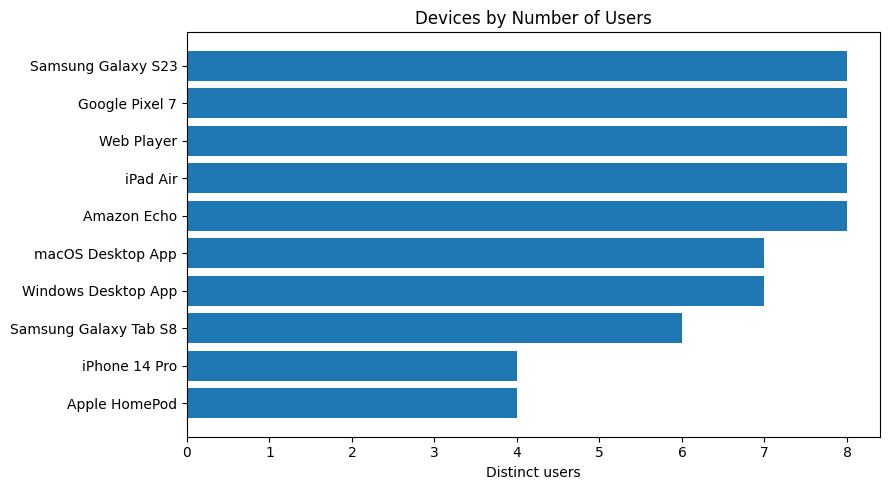

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df['device'][::-1], df['user_count'][::-1])
ax.set_xlabel('Distinct users')
ax.set_title('Devices by Number of Users')
plt.tight_layout()
plt.show()


In [21]:
def diverse_playlists(min_genres=3):
    return query('''
        SELECT p.playlist_id, p.name, COUNT(DISTINCT sg.genre_id) AS distinct_genres
        FROM Playlist p
        JOIN PlaylistSong ps ON p.playlist_id = ps.playlist_id
        JOIN SongGenre sg ON ps.song_id = sg.song_id
        GROUP BY p.playlist_id, p.name
        HAVING COUNT(DISTINCT sg.genre_id) >= ?
        ORDER BY distinct_genres DESC
    ''', (min_genres,))

diverse_playlists(3).head(15)


,playlist_id,name,distinct_genres
0,8,Late Night Drive,15
1,2,Chill Vibes,14
2,4,Road Trip,14
3,9,Acoustic Mornings,14
4,10,Party Anthems,14
5,12,Relaxing Rain,13
6,22,Heartbreak Hits 2,13
7,25,Workout Mix 2,13
8,30,Relaxing Rain 5,13
9,14,Rock Legends,12


In [22]:
def artists_by_playlist_reach(limit=10):
    return query('''
        SELECT ar.name AS artist, COUNT(DISTINCT ps.playlist_id) AS playlists_featuring_artist
        FROM Artist ar
        JOIN Album al ON ar.artist_id = al.artist_id
        JOIN Song s ON al.album_id = s.album_id
        JOIN PlaylistSong ps ON s.song_id = ps.song_id
        GROUP BY ar.artist_id, ar.name
        ORDER BY playlists_featuring_artist DESC
        LIMIT ?
    ''', (limit,))

df = artists_by_playlist_reach(10)
df


,artist,playlists_featuring_artist
0,Michael Jackson,25
1,Adele,25
2,Britney Spears,21
3,Maroon 5,20
4,Post Malone,18
5,LINKIN PARK,15
6,The Proclaimers,14
7,The Cranberries,13
8,Blondie,13
9,Kenny Rogers,13


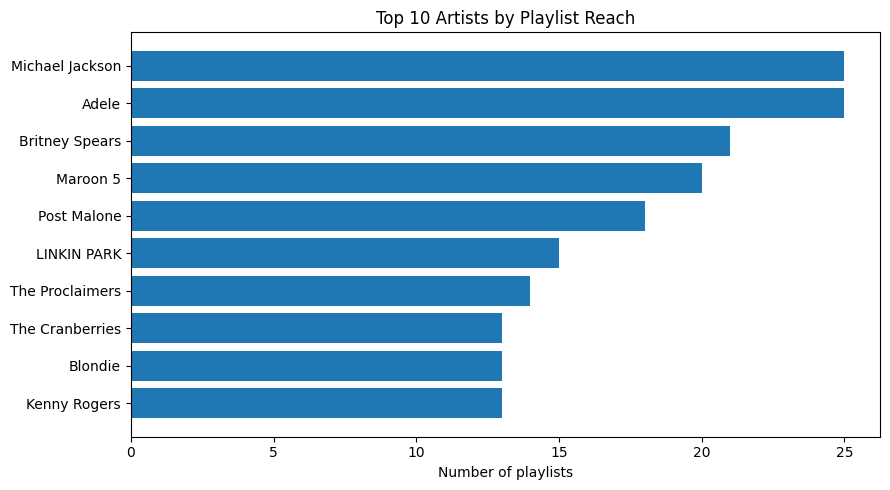

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df['artist'][::-1], df['playlists_featuring_artist'][::-1])
ax.set_xlabel('Number of playlists')
ax.set_title('Top 10 Artists by Playlist Reach')
plt.tight_layout()
plt.show()


In [24]:
def user_genre_preferences():
    return query('''
        SELECT u.name AS user_name, g.name AS genre, COUNT(*) AS song_count
        FROM User u
        JOIN Playlist p ON u.user_id = p.user_id
        JOIN PlaylistSong ps ON p.playlist_id = ps.playlist_id
        JOIN SongGenre sg ON ps.song_id = sg.song_id
        JOIN Genre g ON sg.genre_id = g.genre_id
        GROUP BY u.user_id, u.name, g.genre_id, g.name
        ORDER BY u.name, song_count DESC
    ''')

user_genre_preferences().head(20)


,user_name,genre,song_count
0,Aria Mitchell,Pop,2
1,Aria Mitchell,Pop Rock,2
2,Aria Mitchell,Alternative Rock,1
3,Aria Mitchell,Country,1
4,Aria Mitchell,New Wave,1
5,Aria Mitchell,R&B,1
6,Aria Mitchell,Synth-pop,1
7,Ava Davies,Pop,23
8,Ava Davies,Pop Rock,12
9,Ava Davies,Dance,6
